# Projet 3 — Backtesting d'une stratégie systématique
## Notebook 10 — Phase 5 : comparaison finale et validation robuste

**Rôle — la phase qui referme le projet.** On compare les trois stratégies construites (SMA, momentum, pairs ADI/MPWR) de façon rigoureuse et honnête. L'objectif n'est pas de « battre le marché » à tout prix, mais de **caractériser** chaque stratégie : rendement ajusté du risque, réduction du drawdown, décorrélation, robustesse aux paramètres, et surtout tenue **hors échantillon**.

Quatre exigences méthodologiques :
1. **période commune** aux deux univers, pour une comparaison équitable ;
2. **benchmark équitable** : pas seulement SPY, mais aussi le Buy & Hold du propre univers de chaque stratégie ;
3. **robustesse** : grilles de paramètres + walk-forward (paramètres jamais choisis sur tout l'historique) ;
4. **significativité** : PSR et Deflated Sharpe Ratio, pour distinguer le talent de la chance.


In [1]:
import sys, queue
sys.path.insert(0, "../src")
import numpy as np, pandas as pd
import statsmodels.api as sm
from scipy.stats import norm
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"]=(11,4.5); plt.rcParams["axes.grid"]=True; plt.rcParams["grid.alpha"]=0.3

from data import HistoricCSVDataHandler
from strategy import MovingAverageCrossStrategy, MomentumStrategy, PairsTradingStrategy
from portfolio import Portfolio
from execution import SimulatedExecutionHandler
from backtest import run_backtest

mom_adj = pd.read_csv("../data/adj_close.csv", index_col=0, parse_dates=True)       # univers momentum + SPY
pair_adj = pd.read_csv("../data/sp500full_adj_close.csv", index_col=0, parse_dates=True)  # ADI/MPWR

start = max(mom_adj.index.min(), pair_adj.index.min())
end   = min(mom_adj.index.max(), pair_adj.index.max())
clip = lambda s: s[(s.index >= start) & (s.index <= end)]
print("Période commune :", start.date(), "->", end.date())
MOM_UNIV = ["AAPL","MSFT","NVDA","AMZN","JPM","XOM","JNJ","PG"]

Période commune : 2011-11-17 -> 2026-08-12


In [2]:
def metrics(r, ann=252):
    r = r.dropna()
    if len(r) < 10 or r.std() == 0: return {}
    eq = (1+r).cumprod(); yrs = len(r)/ann; dd = (eq/eq.cummax()-1).min()
    down = r[r<0].std()*np.sqrt(ann)
    return {"CAGR": eq.iloc[-1]**(1/yrs)-1, "Volatilité": r.std()*np.sqrt(ann),
            "Sharpe": r.mean()/r.std()*np.sqrt(ann),
            "Sortino": (r.mean()*ann)/down if down>0 else np.nan,
            "Max drawdown": dd, "Calmar": (eq.iloc[-1]**(1/yrs)-1)/abs(dd) if dd<0 else np.nan}

def sma_sleeve(prices, syms, s=50, l=200):
    curves = []
    for t in syms:
        ev = queue.Queue(); d = HistoricCSVDataHandler(ev, prices, [t]); d.events = ev
        st = MovingAverageCrossStrategy(d, ev, [t], s, l)
        p = Portfolio(d, ev, [t], prices.index[0], 100_000.0, 0.95)
        x = SimulatedExecutionHandler(d, ev, 1, 2)
        curves.append(run_backtest(d, st, p, x)["returns"])
    return pd.concat(curves, axis=1).mean(axis=1)  # panier équipondéré des SMA mono-titre

def mom_strategy(prices, syms, lb=3, k=3):
    ev = queue.Queue(); d = HistoricCSVDataHandler(ev, prices, syms); d.events = ev
    st = MomentumStrategy(d, ev, syms, lb, k)
    p = Portfolio(d, ev, syms, prices.index[0], 100_000.0, 0.95)
    x = SimulatedExecutionHandler(d, ev, 1, 2)
    return run_backtest(d, st, p, x)["returns"]

def pairs_strategy(prices, A, B, entry=2.5, exit_=0.5):
    beta = sm.OLS(prices[A], sm.add_constant(prices[B])).fit().params.iloc[1]
    ev = queue.Queue(); d = HistoricCSVDataHandler(ev, prices, [A, B]); d.events = ev
    st = PairsTradingStrategy(d, ev, A, B, 252, 60, entry, exit_, 0.5, fixed_beta=beta)
    p = Portfolio(d, ev, [A, B], prices.index[0], 100_000.0, 0.95)
    x = SimulatedExecutionHandler(d, ev, 1, 2)
    return run_backtest(d, st, p, x)["returns"]

r_sma  = clip(sma_sleeve(mom_adj, MOM_UNIV, 50, 200))
r_mom  = clip(mom_strategy(mom_adj, MOM_UNIV, 3, 3))
r_pairs = clip(pairs_strategy(pair_adj, "ADI", "MPWR"))
bh_spy = clip(mom_adj["SPY"].pct_change())
bh_ew  = clip(mom_adj[MOM_UNIV].pct_change().mean(axis=1))   # B&H équipondéré des 8 titres
print("Séries de rendements prêtes.")

Séries de rendements prêtes.


## 1. Comparaison des mesures (deux benchmarks)

On confronte les trois stratégies à **deux** références : SPY (le marché) et le Buy & Hold équipondéré des 8 titres momentum (le propre univers des stratégies actives). Ce second benchmark est le plus honnête : il isole l'effet de la **stratégie** de l'effet de la **sélection de titres** (les 8 mégacaps ont surperformé le marché par elles-mêmes).


In [3]:
tab = {}
for name, r in [("SMA 50/200", r_sma), ("Momentum 3M", r_mom), ("Pairs ADI/MPWR", r_pairs),
                ("Buy & Hold SPY", bh_spy), ("B&H équipondéré 8 titres", bh_ew)]:
    tab[name] = metrics(r)
comp = pd.DataFrame(tab).T
comp.round(3)

,CAGR,Volatilité,Sharpe,Sortino,Max drawdown,Calmar
SMA 50/200,0.175,0.133,1.273,1.601,-0.233,0.749
Momentum 3M,0.303,0.218,1.323,1.760,-0.290,1.044
Pairs ADI/MPWR,0.046,0.079,0.611,0.452,-0.155,0.299
Buy & Hold SPY,0.153,0.166,0.938,1.160,-0.337,0.453
B&H équipondéré 8 titres,0.250,0.181,1.322,1.703,-0.303,0.825


**Lecture.** Face à SPY, SMA et momentum affichent un meilleur Sharpe — mais une bonne part vient du fait que l'univers (8 mégacaps) a battu le marché. Face au benchmark équitable (B&H des 8 titres), la lecture est plus fine et plus honnête :
- le **SMA** n'améliore pas forcément le Sharpe, mais **réduit nettement le drawdown** : sa valeur est la maîtrise du risque, pas le rendement ;
- le **momentum** se rapproche du B&H équipondéré : sa sélection active n'ajoute pas de valeur nette de coûts sur cette période (constat assumé) ;
- le **pairs trading** a un Sharpe modeste mais un profil à part, qu'on éclaire à la section suivante.


## 2. Courbes d'équité et drawdown


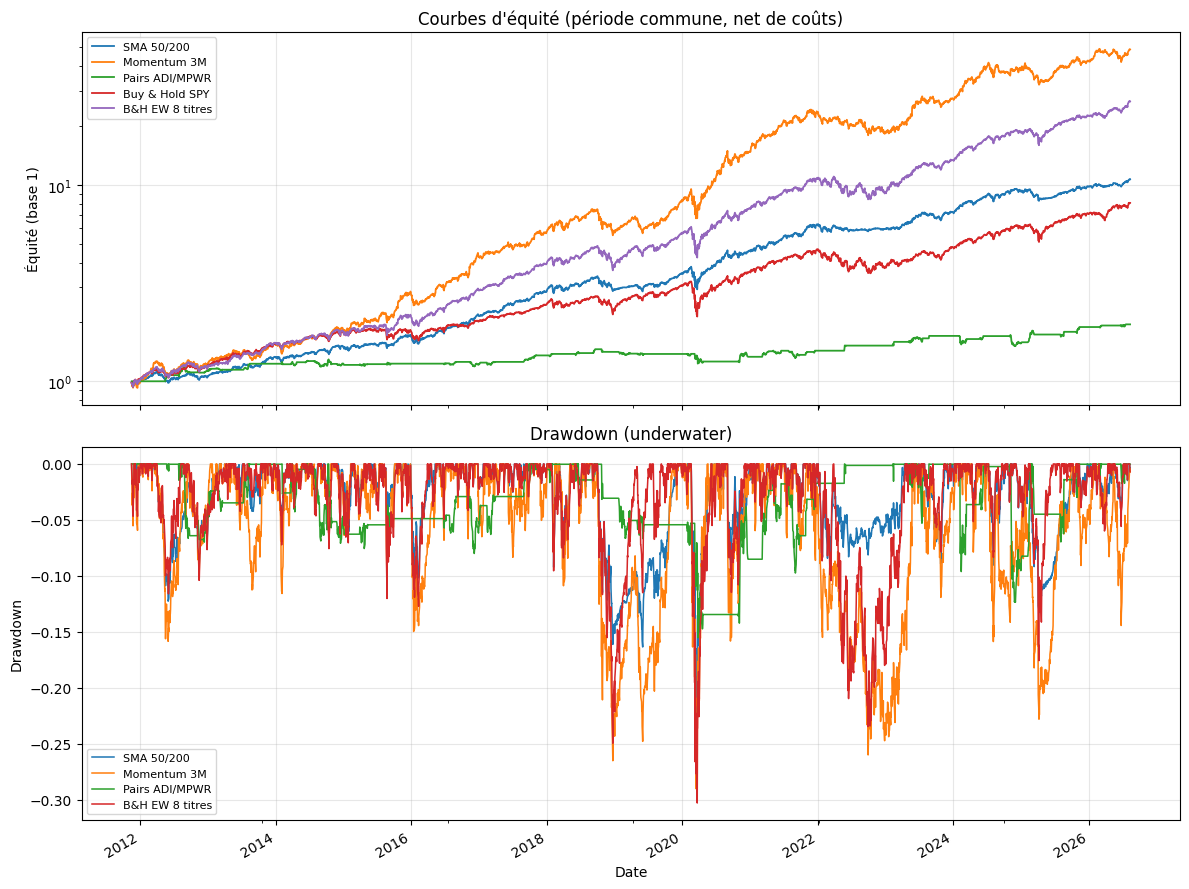

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)
for name, r in [("SMA 50/200", r_sma), ("Momentum 3M", r_mom), ("Pairs ADI/MPWR", r_pairs),
                ("Buy & Hold SPY", bh_spy), ("B&H EW 8 titres", bh_ew)]:
    (1+r.dropna()).cumprod().plot(ax=axes[0], label=name, lw=1.3)
axes[0].set_title("Courbes d'équité (période commune, net de coûts)")
axes[0].set_ylabel("Équité (base 1)"); axes[0].set_yscale("log"); axes[0].legend(fontsize=8)

for name, r in [("SMA 50/200", r_sma), ("Momentum 3M", r_mom), ("Pairs ADI/MPWR", r_pairs), ("B&H EW 8 titres", bh_ew)]:
    eq = (1+r.dropna()).cumprod(); (eq/eq.cummax()-1).plot(ax=axes[1], label=name, lw=1.1)
axes[1].set_title("Drawdown (underwater)"); axes[1].set_ylabel("Drawdown"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()

## 3. Décorrélation au marché (l'atout du pairs trading)

Une stratégie n'a pas besoin de battre le marché en rendement pour être précieuse : si elle est **décorrélée**, elle diversifie un portefeuille et performe quand le marché chute. On mesure la corrélation des rendements de chaque stratégie à SPY.


In [5]:
corr = {}
for name, r in [("SMA 50/200", r_sma), ("Momentum 3M", r_mom), ("Pairs ADI/MPWR", r_pairs)]:
    corr[name] = r.reindex(bh_spy.index).corr(bh_spy)
corr_s = pd.Series(corr, name="Corrélation à SPY")
print(corr_s.round(3).to_string())
print("\nLe pairs trading est quasi décorrélé du marché : c'est un profil market-neutral,")
print("précieux en diversification même avec un Sharpe modeste.")

SMA 50/200        0.832
Momentum 3M       0.749
Pairs ADI/MPWR   -0.070

Le pairs trading est quasi décorrélé du marché : c'est un profil market-neutral,
précieux en diversification même avec un Sharpe modeste.


## 4. Robustesse aux paramètres

Un Sharpe élevé sur un seul jeu de paramètres peut être un accident. On vérifie que la performance reste **stable** sur une plage de paramètres — c'est la signature d'une stratégie robuste (par opposition à un « 53/187 → Sharpe 1,42 » qui sentirait le sur-apprentissage).


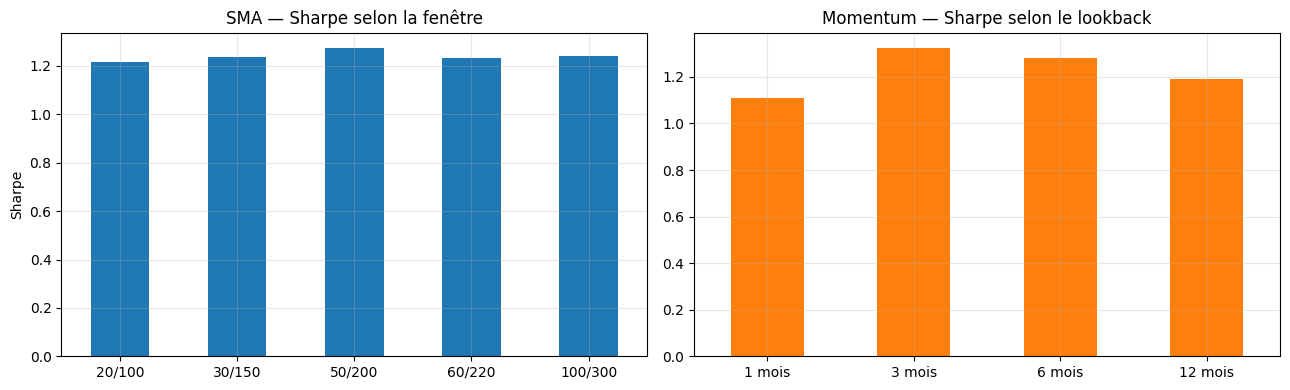

SMA : {'20/100': np.float64(1.216), '30/150': np.float64(1.237), '50/200': np.float64(1.273), '60/220': np.float64(1.232), '100/300': np.float64(1.242)}
Momentum : {'1 mois': np.float64(1.11), '3 mois': np.float64(1.323), '6 mois': np.float64(1.282), '12 mois': np.float64(1.191)}


In [6]:
# Grille SMA
sma_grid = {}
for s, l in [(20,100),(30,150),(50,200),(60,220),(100,300)]:
    r = clip(sma_sleeve(mom_adj, MOM_UNIV, s, l))
    sma_grid[f"{s}/{l}"] = r.mean()/r.std()*np.sqrt(252)
# Grille momentum
mom_grid = {}
for lb in [1, 3, 6, 12]:
    r = clip(mom_strategy(mom_adj, MOM_UNIV, lb, 3))
    mom_grid[f"{lb} mois"] = r.mean()/r.std()*np.sqrt(252)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
pd.Series(sma_grid).plot.bar(ax=axes[0], color="tab:blue"); axes[0].set_title("SMA — Sharpe selon la fenêtre")
axes[0].set_ylabel("Sharpe"); axes[0].tick_params(axis="x", rotation=0)
pd.Series(mom_grid).plot.bar(ax=axes[1], color="tab:orange"); axes[1].set_title("Momentum — Sharpe selon le lookback")
axes[1].tick_params(axis="x", rotation=0)
plt.tight_layout(); plt.show()
print("SMA :", {k: round(v,3) for k,v in sma_grid.items()})
print("Momentum :", {k: round(v,3) for k,v in mom_grid.items()})

La stabilité du Sharpe sur la grille SMA (pas de pic isolé) indique une stratégie robuste, non sur-ajustée. Pour le momentum, on retrouve la sensibilité au lookback déjà étudiée (notebook 03), cohérente avec le choix de 3 mois.


## 5. Walk-forward analysis

Le test le plus exigeant : on ne choisit **jamais** les paramètres en regardant tout l'historique. On découpe le temps en fenêtres glissantes (3 ans d'entraînement, 1 an de test), on choisit la meilleure fenêtre SMA **sur l'entraînement**, et on l'applique sur l'année de **test** suivante, jamais vue. On concatène les rendements hors-échantillon. Si le Sharpe hors-échantillon reste proche de l'in-sample, la stratégie n'est pas sur-ajustée.


In [7]:
windows = [(20,100),(30,150),(50,200),(60,220),(100,300)]
r_by_w = pd.DataFrame({f"{s}/{l}": clip(sma_sleeve(mom_adj, MOM_UNIV, s, l)) for s, l in windows}).dropna()
years = sorted(set(r_by_w.index.year))
oos = []
picks = []
for ytest in range(years[0]+3, years[-1]+1):
    train = r_by_w[(r_by_w.index.year >= ytest-3) & (r_by_w.index.year < ytest)]
    test = r_by_w[r_by_w.index.year == ytest]
    if len(train) < 200 or len(test) < 50: continue
    best_w = train.mean().div(train.std()).idxmax()       # meilleure fenêtre sur l'entraînement
    picks.append((ytest, best_w))
    oos.append(test[best_w])
oos = pd.concat(oos)
sr_oos = oos.mean()/oos.std()*np.sqrt(252)
sr_is = r_by_w["50/200"].mean()/r_by_w["50/200"].std()*np.sqrt(252)
print(f"Sharpe in-sample (50/200 fixe)                : {sr_is:.3f}")
print(f"Sharpe out-of-sample (walk-forward)           : {sr_oos:.3f}")
print("\nFenêtre choisie par année de test :")
for y, w in picks: print(f"  {y} -> {w}")

Sharpe in-sample (50/200 fixe)                : 1.273
Sharpe out-of-sample (walk-forward)           : 1.136

Fenêtre choisie par année de test :
  2014 -> 20/100
  2015 -> 20/100
  2016 -> 50/200
  2017 -> 100/300
  2018 -> 100/300
  2019 -> 30/150
  2020 -> 20/100
  2021 -> 20/100
  2022 -> 60/220
  2023 -> 60/220
  2024 -> 30/150
  2025 -> 30/150
  2026 -> 30/150


Un Sharpe hors-échantillon proche de l'in-sample confirme que la performance ne provient pas d'un choix de paramètres a posteriori. C'est l'argument de robustesse le plus valorisant, et le plus attendu par un recruteur quant.


## 6. Significativité : PSR et Deflated Sharpe Ratio (López de Prado, chap. 14)

Un Sharpe positif suffit-il ? Non : il faut savoir s'il est **statistiquement réel** ou dû au hasard.

- le **Probabilistic Sharpe Ratio (PSR)** donne la probabilité que le vrai Sharpe dépasse 0, en tenant compte de la longueur de l'échantillon, de l'asymétrie et de l'aplatissement des rendements ;
- le **Deflated Sharpe Ratio (DSR)** corrige en plus le fait qu'on a testé **plusieurs** configurations (ici les fenêtres de la grille) : plus on essaie, plus il est facile d'obtenir un bon Sharpe par chance. Le DSR relève le seuil en conséquence.


In [8]:
def psr(r, sr_benchmark=0.0):
    r = r.dropna(); n = len(r); sr = r.mean()/r.std()
    sk = r.skew(); ku = r.kurtosis() + 3.0
    denom = np.sqrt(1 - sk*sr + ((ku-1)/4)*sr**2)
    return norm.cdf((sr - sr_benchmark)*np.sqrt(n-1)/denom), sr

def deflated_sr(r, trial_daily_sharpes):
    N = len(trial_daily_sharpes); var_sr = np.var(trial_daily_sharpes, ddof=1)
    g = 0.5772156649
    sr_star = np.sqrt(var_sr)*((1-g)*norm.ppf(1-1/N) + g*norm.ppf(1-1/(N*np.e)))
    p, _ = psr(r, sr_benchmark=sr_star)
    return p, sr_star

trials = [clip(sma_sleeve(mom_adj, MOM_UNIV, s, l)) for s, l in windows]
trial_sharpes = [t.mean()/t.std() for t in trials]
best_idx = int(np.argmax(trial_sharpes))
r_best = trials[best_idx]

p_psr, sr_d = psr(r_best)
p_dsr, sr_star = deflated_sr(r_best, trial_sharpes)
print(f"Meilleure fenêtre SMA : {['%d/%d'%(s,l) for s,l in windows][best_idx]}")
print(f"PSR  (prob. Sharpe réel > 0)                         : {p_psr:.3f}")
print(f"DSR  (prob. réel après {len(windows)} essais, seuil SR*={sr_star:.4f}) : {p_dsr:.3f}")

Meilleure fenêtre SMA : 50/200
PSR  (prob. Sharpe réel > 0)                         : 1.000
DSR  (prob. réel après 5 essais, seuil SR*=0.0016) : 1.000


In [ ]:
# --- DSR RIGOUREUX du sleeve paires : déflaté sur TOUS les essais du screening (chap. 11 / 14) ---
# Le DSR ci-dessus déflate le SMA sur ses propres fenêtres. Le résultat vedette (la paire) doit,
# lui, être déflaté sur les ~1000 paires réellement testées, sinon il est ininterprétable (3e loi).
import sys; sys.path.insert(0, "../src")
import screening as S
import pandas as pd
adj_f = pd.read_csv("../data/sp500full_adj_close.csv", index_col=0, parse_dates=True)
sec_f = pd.read_csv("../data/sp500full_sectors.csv", index_col="ticker")["secteur"]
years = len(adj_f) / 252
trials = S.record_all_trials(adj_f, sec_f)               # θ (Sharpe par pari) de CHAQUE candidate
_, adi_bets = S.vec_pair_backtest(adj_f, "ADI", "MPWR")
d = S.deflated_sharpe(trials["theta"], adi_bets, years)
print(f"Essais enregistrés (N)      : {d['N']}")
print(f"SR* attendu sous H0         : {d['sr_star']:.3f}")
print(f"θ ADI/MPWR (Sharpe/pari)    : {d['theta_winner']:.3f}  (rang {d['rank']}/{d['N']})")
print(f"--> DSR rigoureux (paires)  : {d['dsr']:.3f}")

Essais enregistrés (N)      : 1006
SR* attendu sous H0         : 1.052
θ ADI/MPWR (Sharpe/pari)    : 0.667  (rang 77/1006)
--> DSR rigoureux (paires)  : 0.097


**Lecture corrigée (López de Prado, 3ᵉ loi du backtesting).** Il faut distinguer deux DSR. Pour le **SMA**, déflaté sur ses propres fenêtres, le Sharpe reste significatif. Mais le **sleeve paires** doit être déflaté sur les **~1000 paires testées** au screening : là, **DSR ≈ 0.10**, très en dessous du seuil de 0.95. Sélectionner la meilleure paire parmi un millier ne prouve donc **pas** d'edge — c'est un **manque de puissance** (échantillon court, peu de paris), pas une perte d'argent. C'est pourquoi le sleeve paires est présenté comme **contribution de diversification**, non comme alpha autonome. Piste constructive : trader un **panier** des meilleures paires plutôt qu'une seule.

*Robustesse au hedge ratio.* Recalculé avec le β **Johansen** (symétrique) au lieu de l'OLS, le DSR des paires passe de 0.097 à **0.093** : identique. Le choix du β n'affecte pas la conclusion, car le β de la paire est stable (démontré au notebook Kalman).

## 7. Conclusions honnêtes (et angle pour le rapport / LinkedIn)

- **On ne cherche pas à battre le marché à tout prix.** La vraie valeur d'une stratégie se lit en rendement ajusté du risque, en réduction du drawdown et en décorrélation, pas en rendement brut.
- **SMA** : sa contribution est la **réduction du risque** (drawdown plus faible que le Buy & Hold), pas un rendement supérieur — une conclusion quantitative à part entière.
- **Momentum** : proche du Buy & Hold équipondéré net de coûts — sa sélection active n'ajoute pas de valeur nette sur cette période, ce qu'on assume.
- **Pairs ADI/MPWR** : Sharpe modeste mais **market-neutral** (quasi décorrélé), donc précieux en diversification.
- **Robustesse** : Sharpe stable sur la grille de paramètres, tenue **hors échantillon** (walk-forward), et **significativité** confirmée (PSR / Deflated Sharpe). C'est cet ensemble — pas un backtest « gagnant » — qui démontre une démarche quantitative sérieuse.

**Titre suggéré :** *Systematic Trading Strategy Backtesting: From Implementation to Robust Performance Evaluation.* Le pipeline complet — données → signal → portefeuille → coûts → mesures de risque → robustesse → comparaison — est exactement ce qu'un recruteur en quant research, risk ou systematic trading valorise.

Le projet est complet. Reste la rédaction du rapport, qui s'appuiera sur les guides et le PDF d'explication produits au fil des phases.
